In [6]:
# ===== 请将您的实验日志全文粘贴到下面的三引号字符串中 =====
data = """
------------------------------ Experiment: KAN, Standard, (LBFGS),  ------------------------------
[0.011457733060584405, 0.019785893291727835, 0.025309584898244197, 0.021702900199859744, 0.020479663981032445, 0.015283476772404882, 0.025424091250009256, 0.018011207692319488, 0.03201977690080931, 0.018812216667967483]
Error u of fuhe active learning(LHS sampling): 2.082865e-02
[0.0025698740433645036, 0.0047227234029111505, 0.006427955092812296, 0.0051749848452758524, 0.004970418339528144, 0.004053013790093966, 0.006230833823265096, 0.004547105317262358, 0.007860818481241011, 0.004568241394690175]
MAE of fuhe active learning(LHS sampling): 5.112597e-03
[5.9782803238862804e-05, 0.00017827489962216362, 0.0002917083899665956, 0.00021449364139640347, 0.000190996112999537, 0.00010637098921374252, 0.0002943538718140366, 0.00014772858702905765, 0.000466890974654521, 0.0001611605792295822]
MSE of fuhe active learning(LHS sampling): 2.111761e-04


------------------------------ Experiment: KAN, Residual, (LBFGS),  ------------------------------
[0.03523795276916203, 0.02035689969980653, 0.015840717201373786, 0.027541519055735125, 0.020289946847612685, 0.9931306878291343, 0.03690532124288868, 0.006877619468318186, 0.02254868591181705, 0.01863862004744341]
Error u of fuhe active learning(LHS sampling): 1.197368e-01
[0.009582603074667165, 0.005025439412019523, 0.00369939131267713, 0.007008477107975575, 0.005056976387941691, 0.5428810821197538, 0.009400938144678444, 0.0019254987381347763, 0.005629208646488482, 0.004820376510253445]
MAE of fuhe active learning(LHS sampling): 5.950300e-02
[0.000565457819024274, 0.0001887131435973623, 0.00011426903426529938, 0.0003454257075234487, 0.0001874738482588383, 0.4491502845949129, 0.000620235836322972, 2.1540469334148928e-05, 0.00023153750545087988, 0.00015819996605850956]
MSE of fuhe active learning(LHS sampling): 4.515831e-02


------------------------------ Experiment: KAN, Failure, (LBFGS),  ------------------------------
[0.029173117430407493, 0.02103582037448376, 0.17436638651131633, 0.0481365011361468, 0.06094251695331755, 0.05988640677158027, 0.3496993794517144, 0.016843816053016443, 0.05093777418752457, 0.05358532142548247]
Error u of fuhe active learning(LHS sampling): 8.646070e-02
[0.008028859627437376, 0.005567944878589427, 0.03807395790252715, 0.014373861862513214, 0.01790989654166235, 0.014506566870222866, 0.0983425492734308, 0.004790614496382681, 0.01510080740332576, 0.014939685776741214]
MAE of fuhe active learning(LHS sampling): 2.316347e-02
[0.00038756500512994945, 0.00020151054747308083, 0.013845365038413857, 0.0010551833146060304, 0.0016912961067497836, 0.0016331850180196375, 0.05568889477888688, 0.00012919920919701283, 0.0011815682245231833, 0.0013075868843409316]
MSE of fuhe active learning(LHS sampling): 7.712135e-03


------------------------------ Experiment: KAN, Failure + Residual, (LBFGS),  ------------------------------
[0.02710347386373422, 0.03362420677191675, 0.020289633661501785, 0.7637219469642818, 0.04193720390452158, 0.022257148376427737, 0.019507365469420886, 0.025609072799977952, 0.9864001472733225, 0.012068058749262851]
Error u of fuhe active learning(LHS sampling): 1.952518e-01
[0.006942666464352102, 0.008375882398195925, 0.005115520217569059, 0.3188088775777137, 0.010350281896214857, 0.005750736700214633, 0.004742574342994683, 0.0069078673844964345, 0.5370794731169517, 0.0030142908941234066]
MAE of fuhe active learning(LHS sampling): 9.070882e-02
[0.0003345251636455839, 0.0005148526719048589, 0.0001874680607865763, 0.2656130553746588, 0.0008008991227084013, 0.00022558899920584847, 0.00017329104337274965, 0.0002986527959885875, 0.4430830457458254, 6.632140330921245e-05]
MSE of fuhe active learning(LHS sampling): 7.112977e-02






"""

In [7]:
import re
import numpy as np


# ===== 解析代码 =====
def parse_error_u(text):
    """
    从日志文本中提取每个实验名称及其对应的 error u 列表（10个数字）
    """
    # 按实验块分割
    blocks = re.split(r'\-{30,} Experiment: ', text)
    experiments = {}
    for block in blocks:
        if not block.strip():
            continue
        lines = block.strip().split('\n')
        if not lines:
            continue
        # 第一行是实验名称（可能包含前导空格，但已经被strip去掉）
        exp_name = lines[0].strip()
        # 在后续行中找以 '[' 开头的行，取第一个这样的行作为 error u 列表
        for line in lines[1:]:
            line = line.strip()
            if line.startswith('['):
                # 提取所有浮点数
                nums = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if nums:
                    values = [float(x) for x in nums]
                    if len(values) == 10:   # 假设就是10个seed
                        experiments[exp_name] = values
                        break
    return experiments

def compute_stats(exp_dict):
    results = []
    for name, vals in exp_dict.items():
        mean = np.mean(vals)
        var = np.var(vals, ddof=1)   # 样本方差
        std = np.std(vals, ddof=1)
        results.append((name, vals, mean, var, std))
    results.sort(key=lambda x: x[2])  # 按均值升序
    return results

def print_results(results):
    print("\n========== 各实验 Error u 统计比较（按均值升序） ==========\n")
    print(f"{'实验名称':<45} {'均值':<12} {'样本方差':<14} {'标准差':<12} {'10个seed的error u'}")
    print("-" * 130)
    for name, vals, mean, var, std in results:
        vals_str = ", ".join([f"{v:.4f}" for v in vals])
        print(f"{name:<45} {mean:.6f}    {var:.6f}     {std:.6f}    [{vals_str}]")
    print("\n")

# 运行
if __name__ == "__main__":
    exp_dict = parse_error_u(data)
    if not exp_dict:
        print("未解析到任何实验数据，请检查文本格式。")
    else:
        results = compute_stats(exp_dict)
        print_results(results)


========== 各实验 Error u 统计比较（按均值升序） ==========

实验名称                                          均值           样本方差           标准差          10个seed的error u
----------------------------------------------------------------------------------------------------------------------------------
KAN, Standard, (LBFGS),  ------------------------------ 0.020829    0.000033     0.005764    [0.0115, 0.0198, 0.0253, 0.0217, 0.0205, 0.0153, 0.0254, 0.0180, 0.0320, 0.0188]
KAN, Failure, (LBFGS),  ------------------------------ 0.086461    0.010511     0.102523    [0.0292, 0.0210, 0.1744, 0.0481, 0.0609, 0.0599, 0.3497, 0.0168, 0.0509, 0.0536]
KAN, Residual, (LBFGS),  ------------------------------ 0.119737    0.094254     0.307007    [0.0352, 0.0204, 0.0158, 0.0275, 0.0203, 0.9931, 0.0369, 0.0069, 0.0225, 0.0186]
KAN, Failure + Residual, (LBFGS),  ------------------------------ 0.195252    0.131193     0.362206    [0.0271, 0.0336, 0.0203, 0.7637, 0.0419, 0.0223, 0.0195, 0.0256, 0.9864, 0.0121]




In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_min_values(exp_dict, top_n=None, save_path=None):
    """
    绘制每个实验的10个seed中的最小值的柱状图（按最小值升序排列）
    
    参数:
        exp_dict: 解析后的实验字典
        top_n: 只显示最小值最小的前N个实验（None表示全部）
        save_path: 保存图片路径，如 'min_values.png'，为None则显示
    """
    # 计算每个实验的最小值
    min_vals = {name: np.min(vals) for name, vals in exp_dict.items()}
    # 按最小值升序排序
    sorted_items = sorted(min_vals.items(), key=lambda x: x[1])
    if top_n is not None:
        sorted_items = sorted_items[:top_n]
    
    names = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(names, values, color='skyblue', edgecolor='black')
    
    # 在柱顶标注数值
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel('Minimum Error u (among 10 seeds)', fontsize=12)
    ax.set_title('Comparison of Minimum Error u across Experiments', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

def plot_seed_trends(exp_dict, highlight_best=True, save_path=None):
    """
    绘制每个实验的10个seed值的折线图（x轴为seed编号1~10）
    
    参数:
        exp_dict: 解析后的实验字典
        highlight_best: 是否用特殊颜色突出显示均值最小的实验
        save_path: 保存图片路径
    """
    # 按均值排序，以便图例有序
    sorted_names = sorted(exp_dict.keys(), key=lambda name: np.mean(exp_dict[name]))
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 定义颜色循环（可自定义）
    colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_names)))
    
    # 找出均值最小的实验（最优）
    best_name = sorted_names[0] if highlight_best else None
    
    for i, name in enumerate(sorted_names):
        vals = exp_dict[name]
        seeds = range(1, 11)
        # 如果是最优实验，用红色粗线突出显示
        if highlight_best and name == best_name:
            line, = ax.plot(seeds, vals, marker='o', linestyle='-', linewidth=3,
                            color='red', label=f"{name} (best mean)", markersize=6)
        else:
            line, = ax.plot(seeds, vals, marker='o', linestyle='-', linewidth=1.5,
                            color=colors[i], label=name, markersize=5, alpha=0.8)
    
    ax.set_xlabel('Seed Index', fontsize=12)
    ax.set_ylabel('Error u', fontsize=12)
    ax.set_yscale('log')
    ax.set_title('Error u across 10 Seeds for Each Experiment', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    plt.xticks(range(1, 11))
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

def plot_seed_comparison(exp_dict, seed_index=1, top_n=None, save_path=None):
    """
    绘制在指定 seed 下，各实验的 Error u 对比柱状图（按该 seed 值升序排列）
    
    参数:
        exp_dict: 解析后的实验字典 {实验名: [10个误差值]}
        seed_index: 指定的 seed 编号（从1开始），默认为1（即第一个seed）
        top_n: 只显示该 seed 值最小的前 N 个实验，None 表示全部显示
        save_path: 保存图片路径，如 'seed5_comparison.png'，为None则显示
    """
    # 检查 seed_index 是否有效
    if seed_index < 1 or seed_index > 10:
        raise ValueError("seed_index 必须在 1 到 10 之间")
    
    idx = seed_index - 1  # 转为0-based索引
    
    # 提取每个实验在该 seed 下的值
    seed_values = {}
    for name, vals in exp_dict.items():
        if len(vals) < idx + 1:
            print(f"警告：实验 '{name}' 的列表长度不足 {seed_index}，跳过")
            continue
        seed_values[name] = vals[idx]
    
    if not seed_values:
        print("没有可用的实验数据，请检查")
        return
    
    # 按该 seed 值升序排序
    sorted_items = sorted(seed_values.items(), key=lambda x: x[1])
    if top_n is not None:
        sorted_items = sorted_items[:top_n]
    
    names = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # 绘图
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(names, values, color='lightcoral', edgecolor='black')
    
    # 在柱顶标注数值
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel(f'Error u at Seed {seed_index}', fontsize=12)
    ax.set_title(f'Comparison of Error u at Seed {seed_index} across Experiments', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()

import numpy as np
import matplotlib.pyplot as plt

def plot_mean_variance_combined(exp_dict, top_n=None, save_path=None):
    """
    在双Y轴图中同时展示各实验的均值和样本方差（按均值升序排列）

    参数:
        exp_dict: 解析后的实验字典 {实验名: [10个误差值]}
        top_n: 只显示均值最小的前N个实验，None表示全部
        save_path: 保存图片路径，为None则直接显示
    """
    # 计算均值和样本方差
    means = {}
    variances = {}
    for name, vals in exp_dict.items():
        means[name] = np.mean(vals)
        variances[name] = np.var(vals, ddof=1) if len(vals) > 1 else 0.0

    # 按均值升序排序
    sorted_names = sorted(means.keys(), key=lambda x: means[x])
    if top_n is not None:
        sorted_names = sorted_names[:top_n]

    names = sorted_names
    mean_vals = [means[n] for n in names]
    var_vals = [variances[n] for n in names]

    # 创建图形和双轴
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax2 = ax1.twinx()

    # 左轴：均值柱状图
    x_pos = np.arange(len(names))
    bars = ax1.bar(x_pos, mean_vals, color='skyblue', edgecolor='black',
                   alpha=0.8, label='Mean Error u')
    ax1.set_ylabel('Mean Error u', fontsize=12, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # 在柱顶标注均值数值
    for bar, val in zip(bars, mean_vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8, color='blue')

    # 右轴：方差折线图（用红色圆点标记）
    line, = ax2.plot(x_pos, var_vals, marker='o', linestyle='-', color='red',
                     linewidth=2, markersize=8, label='Variance')
    ax2.set_ylabel('Sample Variance', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 在折线上标注方差数值
    for i, val in enumerate(var_vals):
        ax2.text(i, val + 0.001, f'{val:.6f}', ha='center', va='bottom',
                 fontsize=7, color='red')

    # 合并图例
    lines = [bars, line]
    labels = ['Mean Error u', 'Variance']
    ax1.legend(lines, labels, loc='upper left', fontsize=10)

    ax1.set_title('Mean and Variance of Error u across 10 Seeds', fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图已保存至 {save_path}")
    else:
        plt.show()



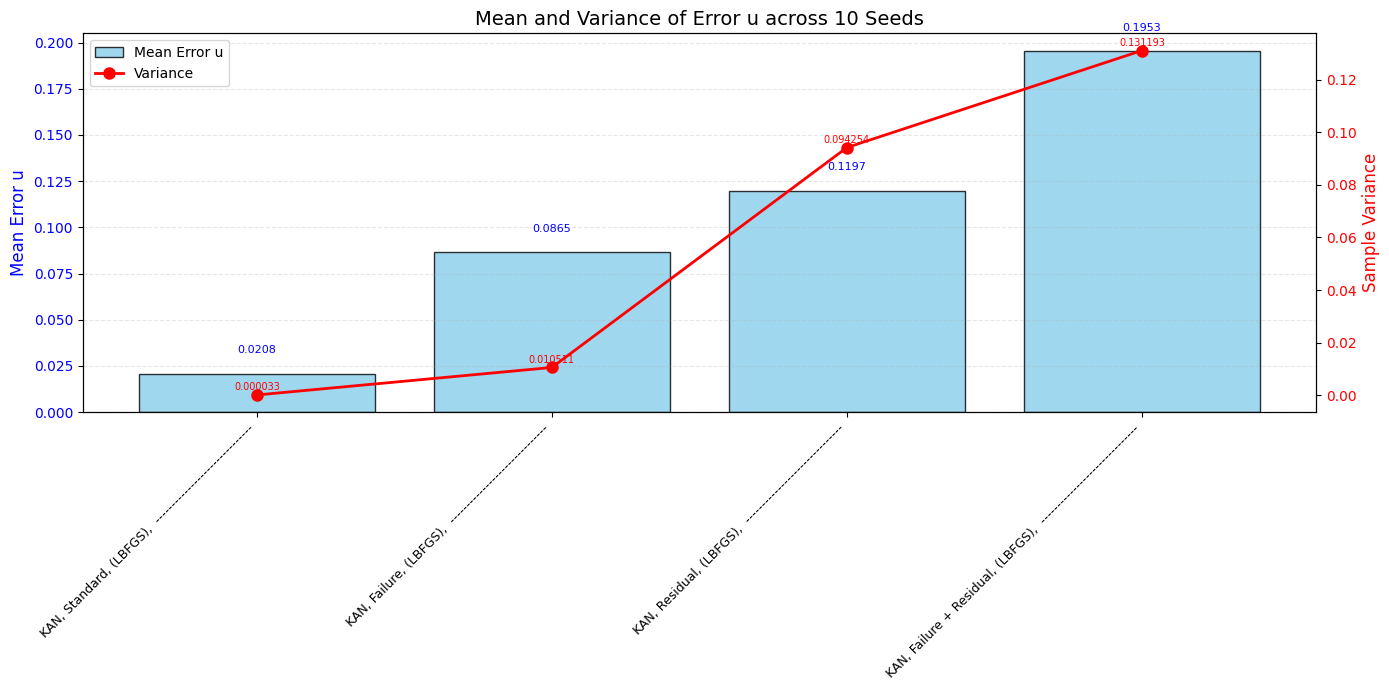

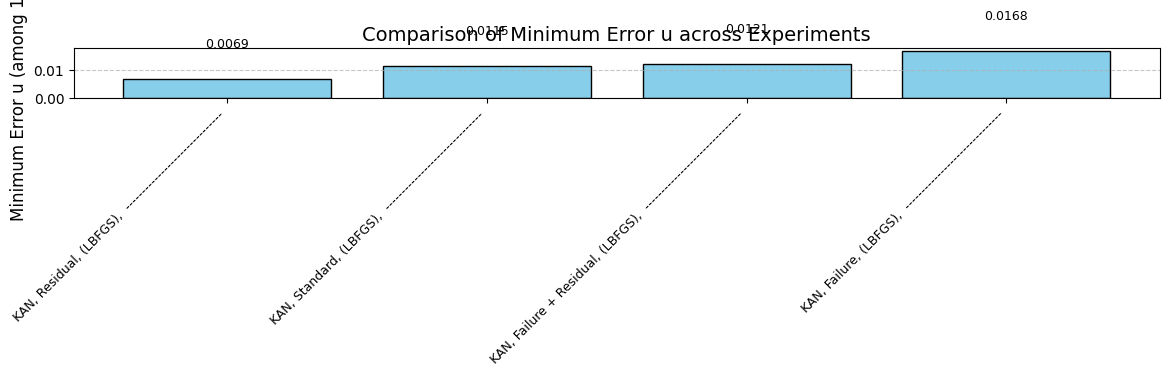

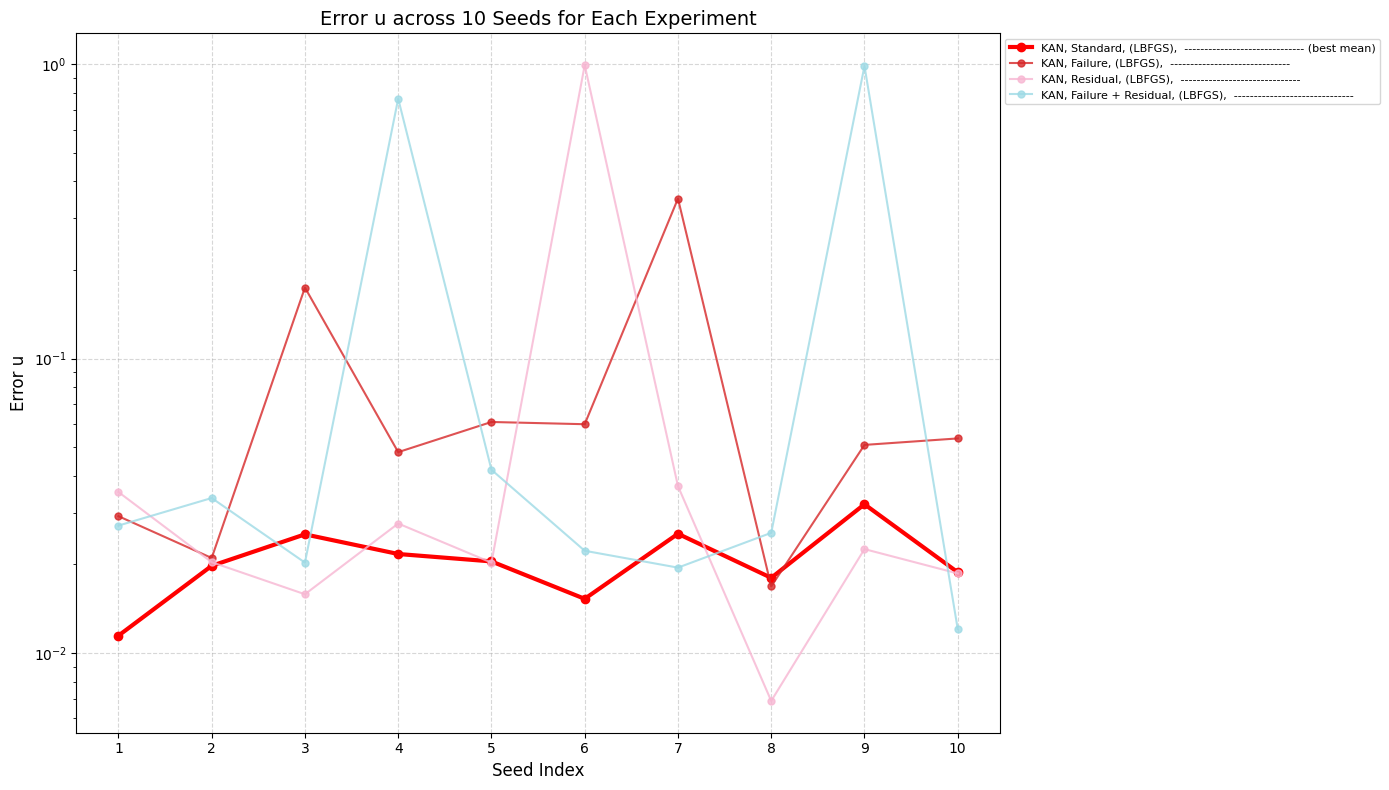

In [9]:

plot_mean_variance_combined(exp_dict)

# 绘制最小值柱状图（显示全部实验）
plot_min_values(exp_dict)

# 绘制折线图
plot_seed_trends(exp_dict)


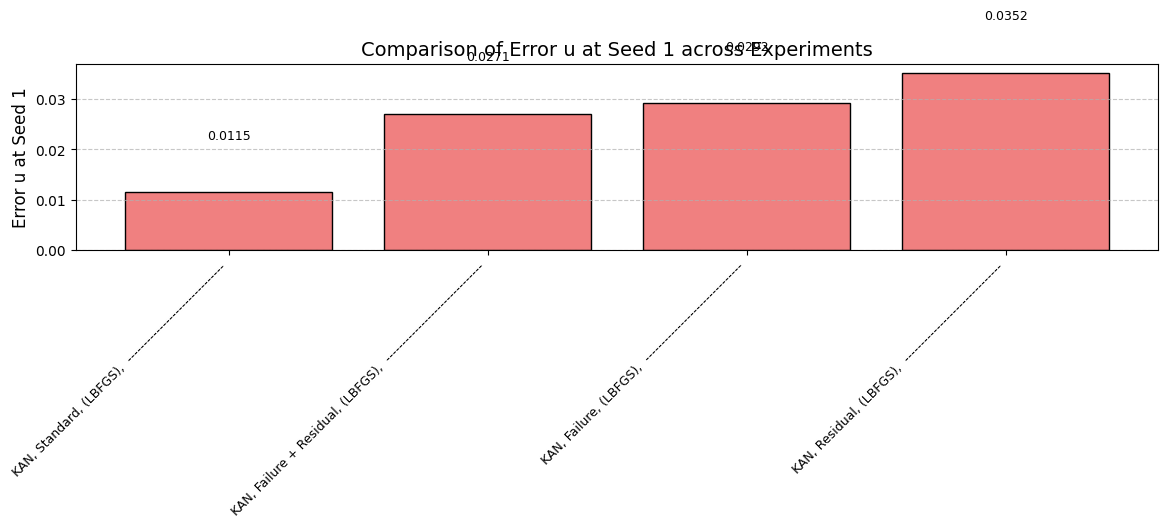

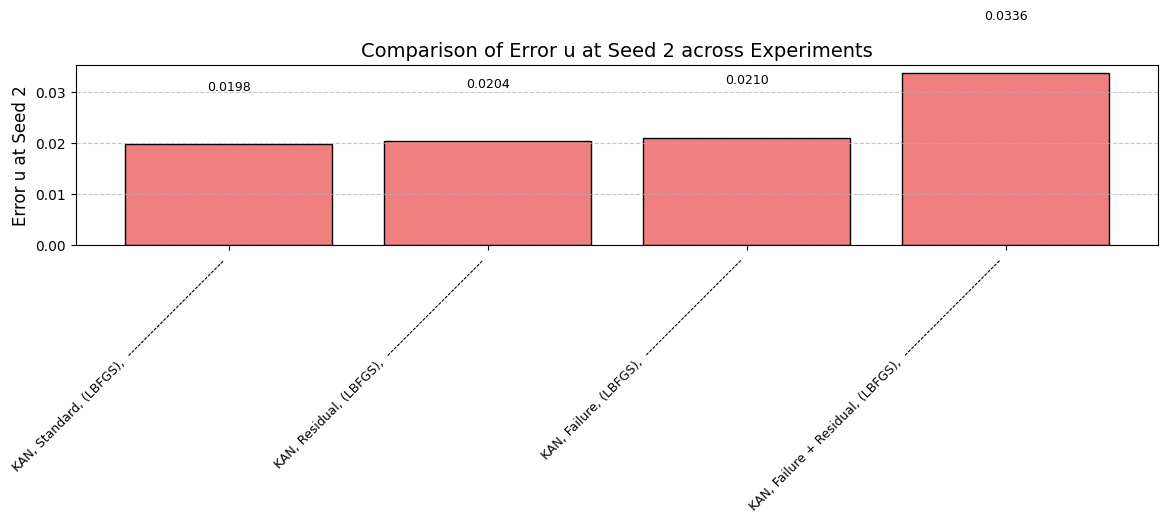

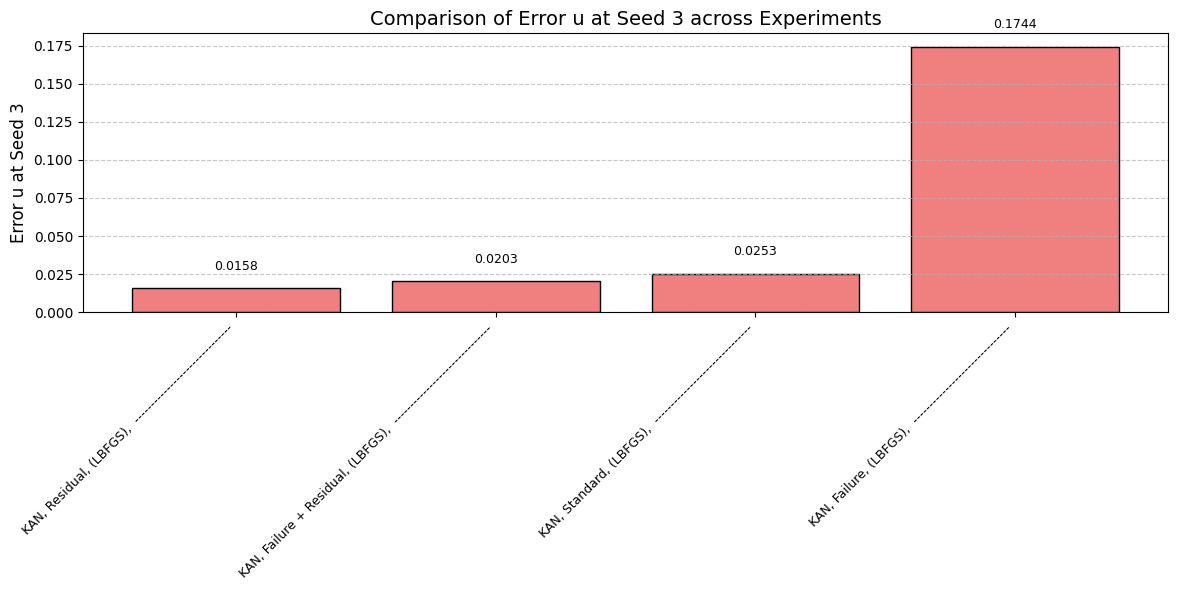

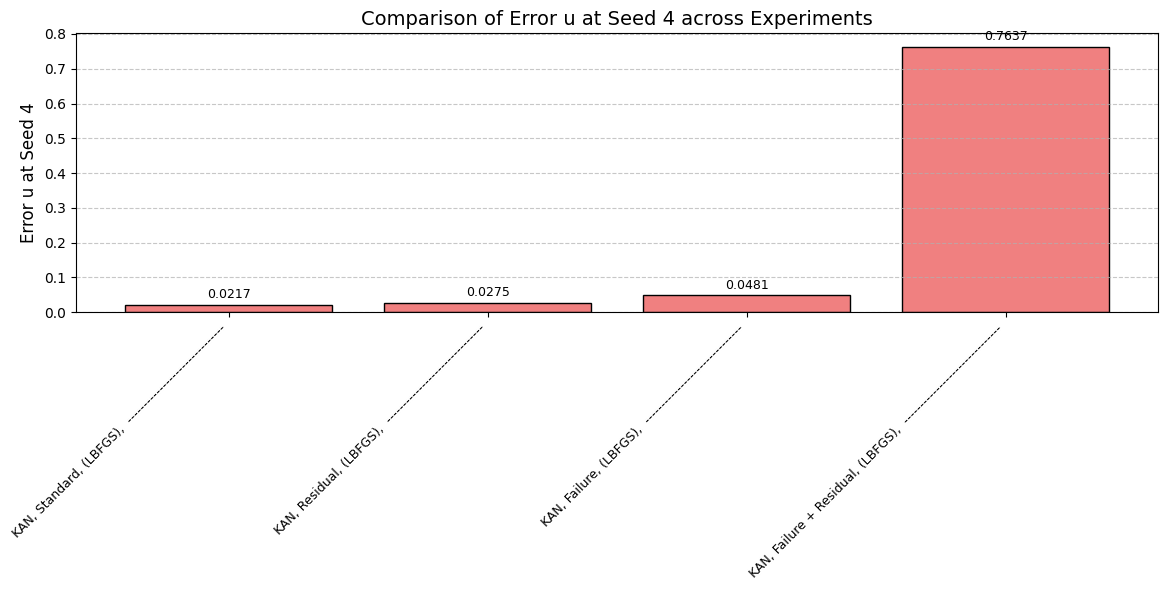

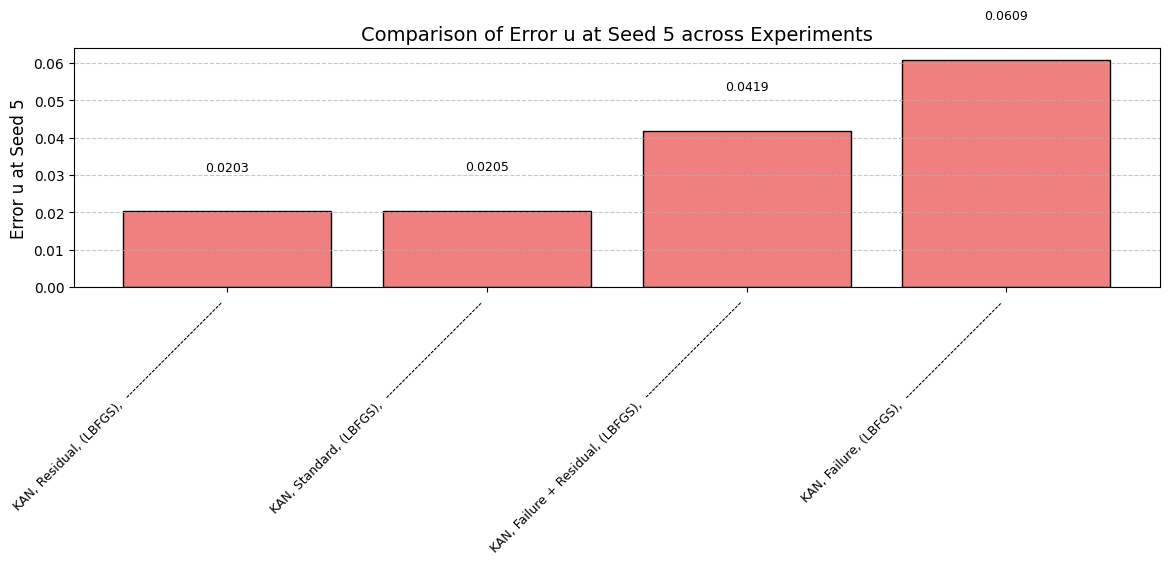

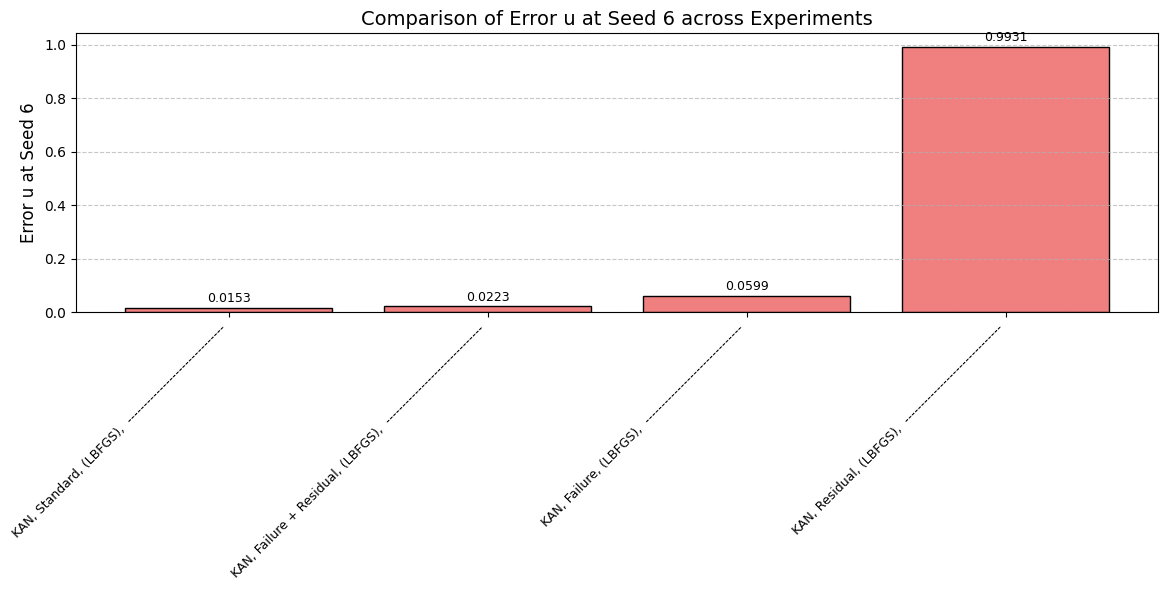

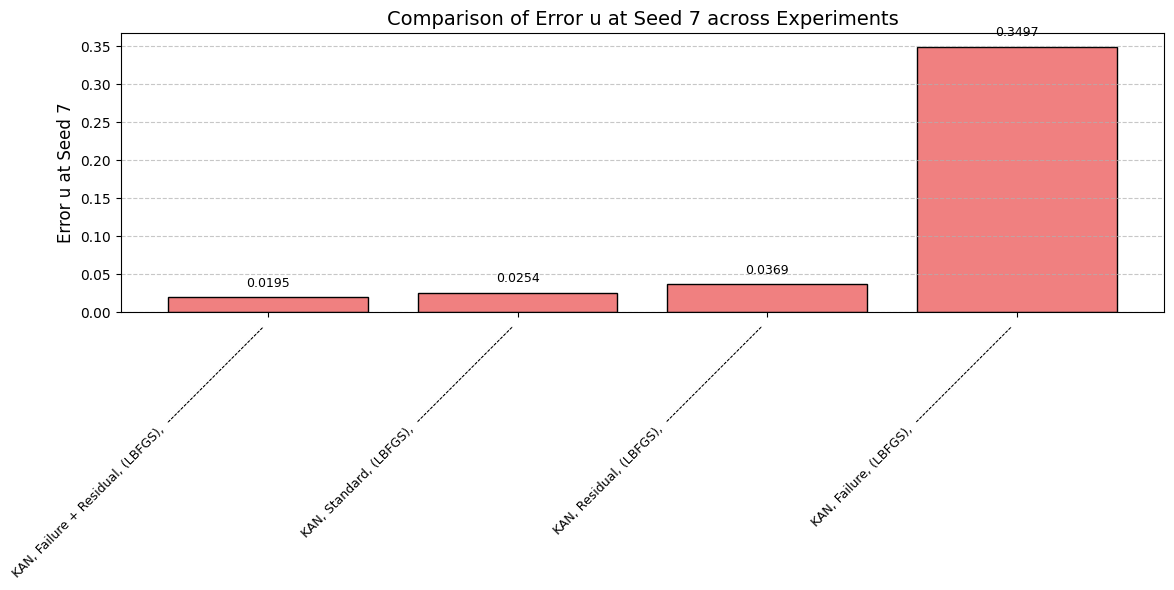

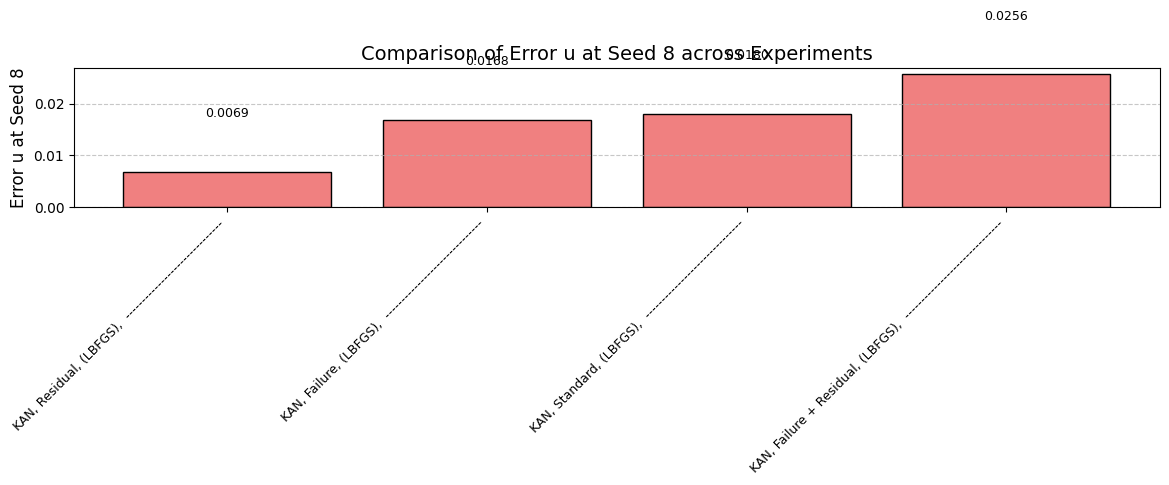

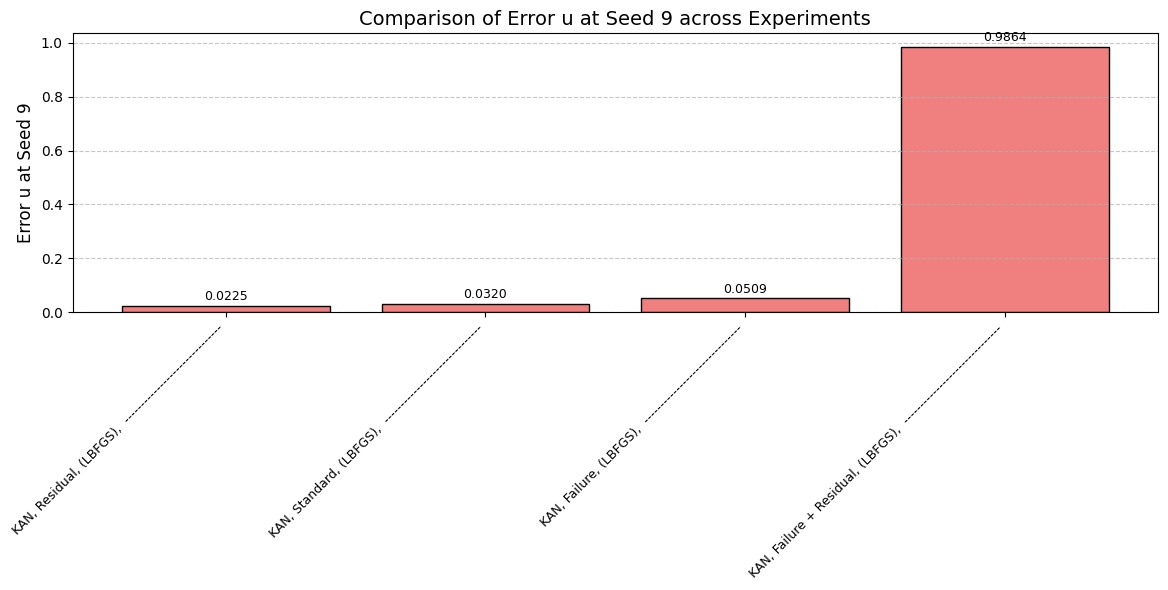

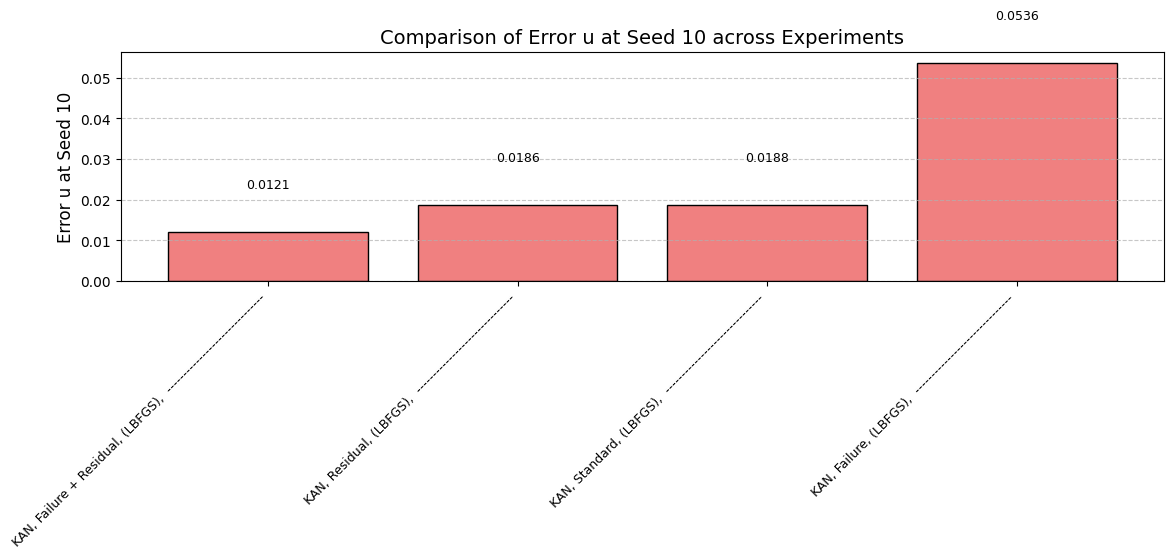

In [10]:
for i in range(10):
    plot_seed_comparison(exp_dict, seed_index = i+1)
# plot_seed_comparison(exp_dict, seed_index=10)